In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("bank-additional.csv", sep = ";")
df.head(15)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
5,32,services,single,university.degree,no,no,no,cellular,sep,thu,...,3,999,2,failure,-1.1,94.199,-37.5,0.884,4963.6,no
6,32,admin.,single,university.degree,no,yes,no,cellular,sep,mon,...,4,999,0,nonexistent,-1.1,94.199,-37.5,0.879,4963.6,no
7,41,entrepreneur,married,university.degree,unknown,yes,no,cellular,nov,mon,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
8,31,services,divorced,professional.course,no,no,no,cellular,nov,tue,...,1,999,1,failure,-0.1,93.200,-42.0,4.153,5195.8,no
9,35,blue-collar,married,basic.9y,unknown,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no


1. Identify the target variable

The target variable for the analysis and based on the instruction should be "y" which refers to whether the client subscribed to the product after the marketing campaign contacted them, this is the whole business objective of the campaign. Other variables that could be valid targets are "campaign", which refers to the number of times the client was contacted during the campaign, and "duration" which refers to the call duration (in seconds).

However, they are not to be treated as prediction objectives because they are not aligned with the goals of the campaign. The bank (in this instance) does not want to make predictions on how many times they will call someone, they want to predict whether calling them is actually worth it. This is what the "campaign" variable refers to. Also, it can be influenced by other outside variables. What if the customer didn't answer? They might get called again in the future. When it comes to "duration", this shouldn't be treated as a target objective since in the context of the bank, they probably don't care about predicting call length, they care more about whether the customers subscribe or not. And it can also create data leakage because we can only know the call duration after it happens. The question is "Should we call this person?" and at that moment we don't know the duration. If we were to use duration, we would be modelling something that happens after the decision.


2. Data loading and exploration

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

We can see that the dataset has 4119 entries. It also has 10 numerical variables, including age, emp.var.rate, nr.employed, etc.. Note that variables like duration, campaign, pdays, previous and age are all integer-numerical variables. And 11 categorical variables like, poutcome, month, day_of_week, etc... For a total of 21 features. From this table, we can also see that all features have 4119 non-null values, meaning there are no cells with empty values, but missing values may be formatted in a different way. We will inspect this later.

Let us now inspect some of the basic summary statistics for the numerical variables.

In [4]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


From this we can already tell that standardization will be needed, as variables like duration (for example) have a maximum value of 3643 and a emp.var.rate (for example) has a maximum value of 1.4. We can also see that cons.conf.index has only negative values. Another interesting observation is that variable pdays has most of its entries around 960, with the 25%, 50% and 75% of its values being 999. This variable does not go beyond this threshold in fact. Finally, we can observe that something similar happens with variable previous, where mean is 0.19 and 25th, 50th and 75th percentile are all 0.

<function matplotlib.pyplot.show(close=None, block=None)>

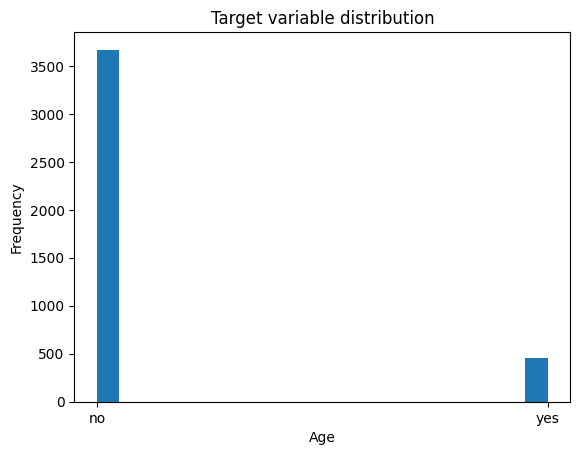

In [9]:
plt.hist(df["y"], bins = 20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Target variable distribution")
plt.show

From this histogram of the target variable, we can already tell there is huge class imbalance. Where the "yes" response has around 500 entries and "no" response has more than 3500 entries.

In [42]:
tokens = ["unknown", "?", "na", "n/a", "none", "null", "", "NaN"]  # list keeps order

token_counts = {}

for col in df.select_dtypes(include=["object", "string"]).columns:
    s = df[col].astype(str).str.strip().str.lower()
    counts = {t: int((s == t).sum()) for t in tokens}
    counts = {t: n for t, n in counts.items() if n > 0}
    if counts:
        token_counts[col] = counts

token_counts

{'job': {'unknown': 39},
 'marital': {'unknown': 11},
 'education': {'unknown': 167},
 'default': {'unknown': 803},
 'housing': {'unknown': 105},
 'loan': {'unknown': 105}}

From this line of code, we can see that there are in fact missing values. After checking for different common "missing-value tokens", the only one introduced was unknown. It showed that variable default is the on with the most missing values: 803. Then, education, housing and loan variables depict similar counts of missing values (around 100), and for job and marital the missingness stays below 50.

Let's inspect now the distribution of some of the "interesting" numerical variables we saw on the df.describe() line of code and some for the categorical variables.

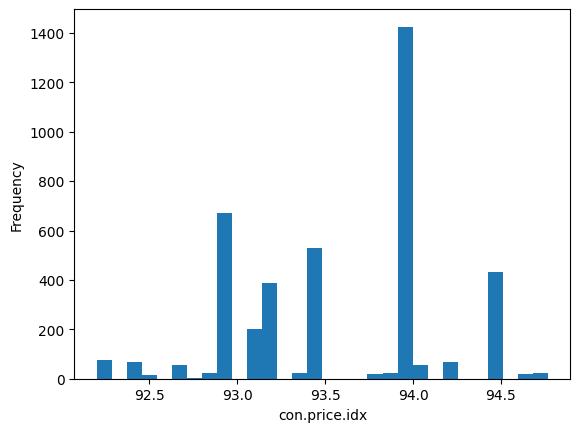

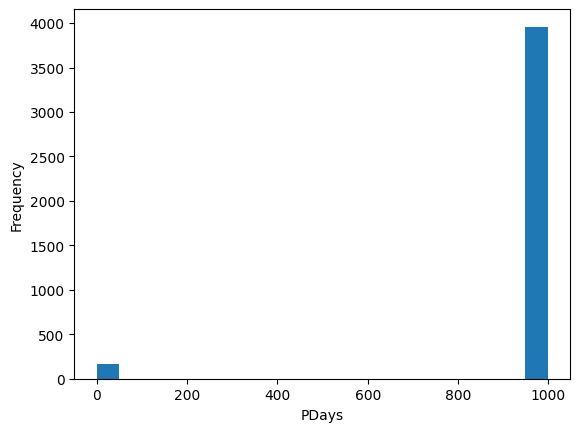

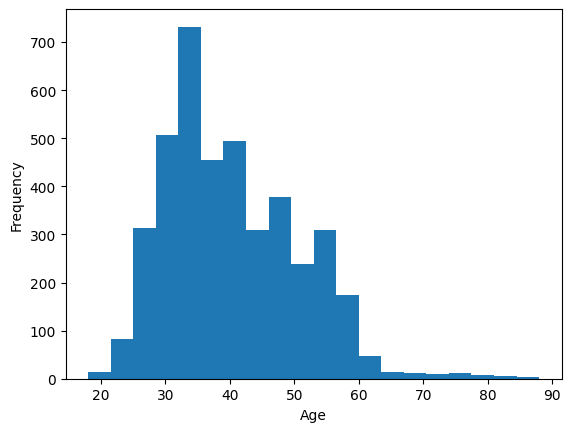

In [25]:
plt.hist(df["cons.price.idx"], bins = 30)
plt.xlabel("con.price.idx")
plt.ylabel("Frequency")
plt.show()

plt.hist(df["pdays"], bins = 20)
plt.xlabel("PDays")
plt.ylabel("Frequency")
plt.show()

plt.hist(df["age"], bins = 20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

These histograms for numerical variables, give us valuable information of the distribution of the variables. First, cons.price.idx shows a "weird" behavior, with a huge spike at 94 and the other frequencies remain somewhat low in comparison. For pdays, we can see great imbalance, where the only values shown go from either 0 to around 50, and from 950 to 1000. With a huge difference from the count of the first compared to the latter range. Finally, age shows a more normal distribution with a slight skewness to the right. The histogram shows that most of the respondents lie in the 25 to 48 group (approximately)

Let's now inspect for the categorical variables

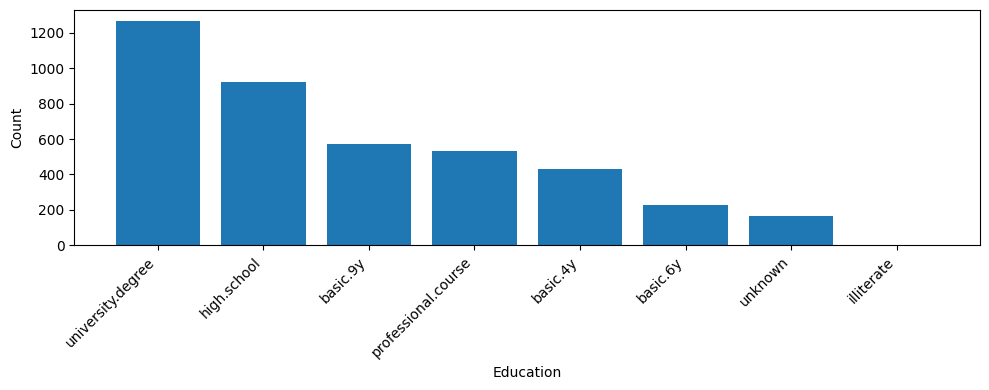

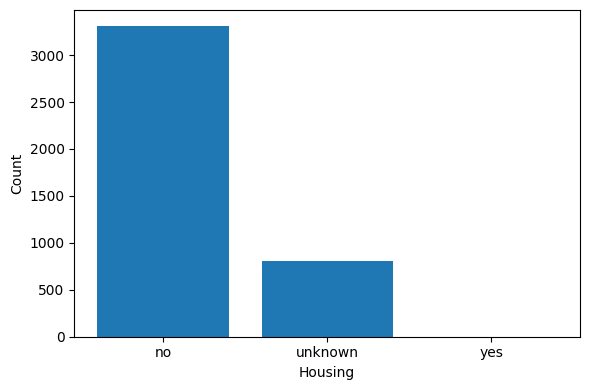

In [65]:
counts = df["education"].value_counts()

plt.figure(figsize=(10,4))
plt.bar(counts.index, counts.values)
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

counts = df["housing"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.xlabel("Housing")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

For the education variable, we can see most of the respondents lie on the university degree category and high school. There are very few illiterate respondents. For the housing feature, it seems to be somewhat balanced with most of the observations lying on the "yes" response.

From this and the past stated information, we can identify 2 variables to have special consideration before modelling. pdays and duration.

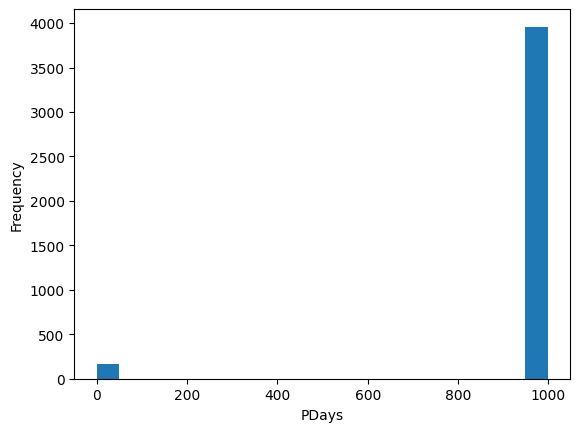

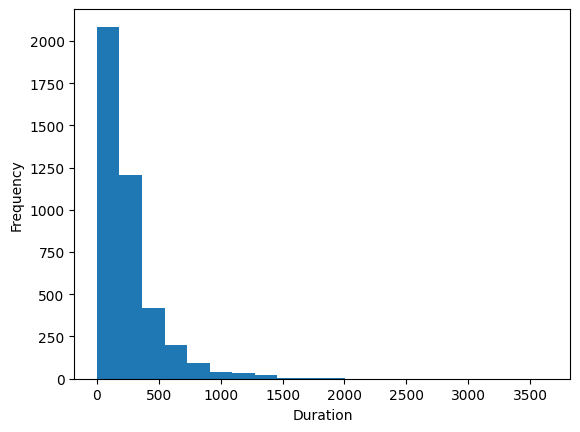

In [38]:
plt.hist(df["pdays"], bins = 20)
plt.xlabel("PDays")
plt.ylabel("Frequency")
plt.show()

plt.hist(df["duration"], bins = 20)
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

Pdays requires special handling because it is extremely skewed. It refers to "days since last contact in a previous campaign". Most values are 999, which translates to "never previously contacted". This creates huge skewness on the data. treating 999 as an actual number may distort the distribution and mislead the model. A reasonable approach would be to replace 999 with NaN or create a binary feature such as "previously_contacted", where if the value is different from 999 the observation would be now "yes" and if not then the observation would be marked as "no".

On the other hand, duration feature also requires special consideration because it can cause data leakage. The goal for this model is to decide "who to call", but call duration is only known after the call has occurred. Including it as a feature may make the model look unrealistically "good", as longer calls usually correlate to success, but it probably won't work in real deployment. Therefore, we should exclude this variable for a pre-call model.

I will now change the pdays variable so that 999 actually represents something. I will create a new feature called "contacted" where if the value for the observation is 999, then in this new feature it will be marked as yes. Otherwise, it will be marked as "no". I do this because 999 isn't a real number of days in this dataset. 999 is a special code meaning "never previously contacted". If we do not change this, we will have extreme skewness, where the distribution is dominated by 999. Also, the model will misinterpret the value. Logistic regression will treat 999 as a large amount of days since last contact. Which would imply the client was contacted a long time ago, which is not true. Note that I do this before splitting because the variable is not "learning" anything from the dataset. It is not fitting or averaging anything. It is just a fixed meaning

It is important to know that I didn't create another feature referring to the actual days since previously contacted for those who did not have 999 because the extent of missingness for that variable would be too high. From the histogram before, we already knew that the extent of values different than 999 was very low (below 5%). Adding this new column would have 96% of NaNs and around 4% of non-missing values.

In [57]:
df["contacted"] = np.where(df["pdays"] == 999, "no", "yes")

df.drop(columns=["pdays",])

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,contacted
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114,30,admin.,married,basic.6y,no,yes,yes,cellular,jul,thu,...,1,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,no,no
4115,39,admin.,married,high.school,no,yes,no,telephone,jul,fri,...,1,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,no,no
4116,27,student,single,high.school,no,no,no,cellular,may,mon,...,2,1,failure,-1.8,92.893,-46.2,1.354,5099.1,no,no
4117,58,admin.,married,high.school,no,no,no,cellular,aug,fri,...,1,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no,no


3. Splitting the data

In [58]:
y = df["y"]
x = df.drop(columns=["y"])

x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.3, random_state=42,
    stratify = y
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=42,
    stratify = y_temp
)

I split the data into 70/15/15 (train, validation and test) in order to maximize the training data size while still reserving enough to validate for model selection. And a final untouched test set for unbiased evaluation

I used stratifies sampling on y because the target is very imbalanced. Stratification will preserve the class proportions across splits. This way, I can prevent misleading evaluation due to an unusually low or high number of negatives or positives in validation or test set.

Splitting must be done before imputation, encoding, scaling and resampling. If we were to perform these steps before splitting, information would be leaked from validation or test into training. For imputation (for example), if we were to fill missing values using statistics computed on the full dataset, then the training set will be using information from the validation and test set. Or if we were to scale before splitting, the training features will be transformed using the mean, standard deviation, minimum and maximum of validation and test set too. Creating data leakage.

4. Missing values

In [59]:
missing_counts = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
}).sort_values("missing_count", ascending=False)

token = "unknown"

cat_cols = df.select_dtypes(include=["object", "string"]).columns

unknown_count = df[cat_cols].apply(
    lambda s: s.astype(str).str.strip().str.lower().eq(token).sum()
)

unknown_pct = (unknown_count / len(df) * 100).round(2)

missing_summary2 = missing_summary.join(pd.DataFrame({
    "unknown_count": unknown_count,
    "unknown_pct": unknown_pct
}), how="left").fillna(0)

missing_summary2.sort_values(["missing_count", "unknown_count"], ascending=False)

,missing_count,missing_pct,unknown_count,unknown_pct
default,0,0.0,803.0,19.50
education,0,0.0,167.0,4.05
loan,0,0.0,105.0,2.55
housing,0,0.0,105.0,2.55
job,0,0.0,39.0,0.95
marital,0,0.0,11.0,0.27
age,0,0.0,0.0,0.00
y,0,0.0,0.0,0.00
nr.employed,0,0.0,0.0,0.00
euribor3m,0,0.0,0.0,0.00


Taking information from point 2 (Data exploration), we can see that the only missing value "token" was "unknown". There are no explicit missing values (NaN) in the whole dataset.

In contrast, variable default has 19.5% of implicit missing values (unknown), education has 4.05% and both loan and housing have 2.55%. Other variables have either 0 or less than 1%.

Based on the table, I will manage missing values in 2 ways, imputation and maintaining "unknown" and treating it as a deparate category for 1 feature only.

I will impute the values with the mode for the following categories: education, loan, housing, job, and marital. Mainly because imputing the values will not distort with the distribution as their extent is very low (>5%). These values are likely missing at random, and they will add unnecessary noise to the model without providing any relevant information.

For feature default, I will treat "unknown" as a separate category. Default variable refers to if a person has credit in default. being financial data, it likely means that there is a lack of credit history or a refusal to disclose. Which could provide valuable information to the model. Also, given that the extent of missingness is almost 20% (almost 1/5 of the observation) it likely means there are highly predictive signals on these "unknown" responses

In [68]:
cols_to_impute = ["education", "loan","housing","job","marital"]
cols_to_keep = ["default"]

for dataset in [x_train, x_val, x_test]:
    dataset.replace('unknown', np.nan, inplace=True)

mode_imputer = SimpleImputer(strategy = "most_frequent")

mode_imputer.fit(x_train[cols_to_impute])

x_train[cols_to_impute] = mode_imputer.transform(x_train[cols_to_impute])
x_val[cols_to_impute] = mode_imputer.transform(x_val[cols_to_impute])
x_test[cols_to_impute] = mode_imputer.transform(x_test[cols_to_impute])


education      0
loan           0
housing        0
job            0
marital        0
default      106
dtype: int64
default
no    512
Name: count, dtype: int64


We only perform the model_imputer.fit() operation on the x_train because this way we prevent data leakage. If we fit on the whole dataset, the imputer will see the distribution of the future data. If the most common eduction level in the test set is different from the training set, the imputer would have be influenced by information it shouldn't have access to. We also only fit on the train set because this way we ensure that the model is evaluated on how well it handles data using the same logic it was trained with. If I were to use a different Mode for the test set, I would be introducing a mismatch between the training and test sets.